# Trimmed Kalman Smoother

All functions live in separate modules. Import them here and run the experiments below.

| Module | Contents |
|---|---|
| `projection.py` | `project_capped_simplex` |
| `smoother.py` | `weighted_batch_smoother` |
| `losses.py` | `measurement_losses`, `compute_innovation_losses`, `summarize_innovation_loss_near_jumps` |
| `measurement_trim.py` | `trimmed_kalman_smoother` |
| `innovation_trim.py` | `innovation_trimmed_kalman_smoother`, `warm_start_nu_from_jump_score`, `detection_near_jumps` |
| `simulation.py` | `simulate_constant_velocity_data`, `simulate_general_smooth_signal` |
| `experiments.py` | `run_one_trial` |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from projection       import project_capped_simplex
from smoother         import weighted_batch_smoother
from losses           import (
    compute_innovation_losses,
    summarize_innovation_loss_near_jumps,
)
from measurement_trim import trimmed_kalman_smoother
from innovation_trim  import (
    innovation_trimmed_kalman_smoother,
    warm_start_nu_from_jump_score,
    detection_near_jumps,
)
from simulation       import (
    simulate_constant_velocity_data,
    simulate_general_smooth_signal,
)
from experiments      import run_one_trial

---
## 1. Capped-simplex projection — quick sanity check

In [2]:
np.random.seed(0)
N, h = 20, 15
y = np.random.randn(N)
w = project_capped_simplex(y, h)

print("Projected weights:", w)
print("sum(w) =", np.sum(w), "  target h =", h)
print("min(w) =", np.min(w), "  max(w) =", np.max(w))

Projected weights: [1.         0.92942268 1.         1.         1.         0.
 1.         0.37790827 0.42604662 0.93986398 0.67330905 1.
 1.         0.65094049 0.97312871 0.8629398  1.         0.32410721
 0.84233318 0.        ]
sum(w) = 14.99999999996752   target h = 15
min(w) = 0.0   max(w) = 1.0


---
## 2. Constant-velocity model — Gaussian smoother baseline

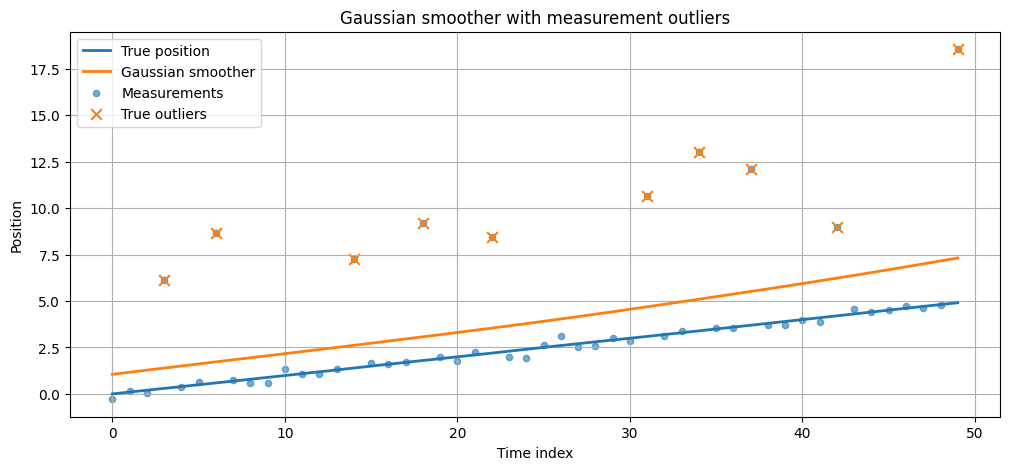

Gaussian smoother position MSE: 2.479154507755536


In [3]:
G, H, Q, R, x_true, z, outlier_idx = simulate_constant_velocity_data()

x_gauss = weighted_batch_smoother(
    G, H, Q, R, z,
    omega=np.ones(len(z)),
    x0_prior=np.array([1, 0]),
    P0=1.0 * np.eye(2),
)

plt.figure(figsize=(12, 5))
plt.plot(x_true[:, 1], label="True position", linewidth=2)
plt.plot(x_gauss[:, 1], label="Gaussian smoother", linewidth=2)
plt.scatter(np.arange(len(z)), z, s=20, alpha=0.6, label="Measurements")
plt.scatter(outlier_idx, z[outlier_idx], s=60, marker="x", label="True outliers")
plt.legend(); plt.title("Gaussian smoother with measurement outliers")
plt.xlabel("Time index"); plt.ylabel("Position"); plt.grid(True)
plt.show()

mse_gauss = np.mean((x_gauss[:, 1] - x_true[:, 1]) ** 2)
print("Gaussian smoother position MSE:", mse_gauss)

---
## 3. Constant-velocity model — measurement-trimmed smoother

In [4]:
N = len(z)
h = N - len(outlier_idx)   # keep all non-outlier measurements

x_trim, omega_trim, losses_trim, history = trimmed_kalman_smoother(
    G, H, Q, R, z,
    h=h, gamma=0.5, max_iter=50, tol=1e-8,
    x0_prior=np.array([1, 0]),
    P0=1.0 * np.eye(2),
    verbose=True,
)

mse_trim = np.mean((x_trim[:, 1] - x_true[:, 1]) ** 2)
print("\nResults")
print("Gaussian MSE:", mse_gauss)
print("Trimmed MSE:", mse_trim)
print("Improvement factor:", mse_gauss / mse_trim)
print("sum(omega_trim) =", np.sum(omega_trim))

iter 00 | omega change = 2.828e+00 | min omega = 0.000 | max omega = 1.000
iter 01 | omega change = 0.000e+00 | min omega = 0.000 | max omega = 1.000

Results
Gaussian MSE: 2.479154507755536
Trimmed MSE: 0.0007645532977847003
Improvement factor: 3242.6182908881665
sum(omega_trim) = 40.0


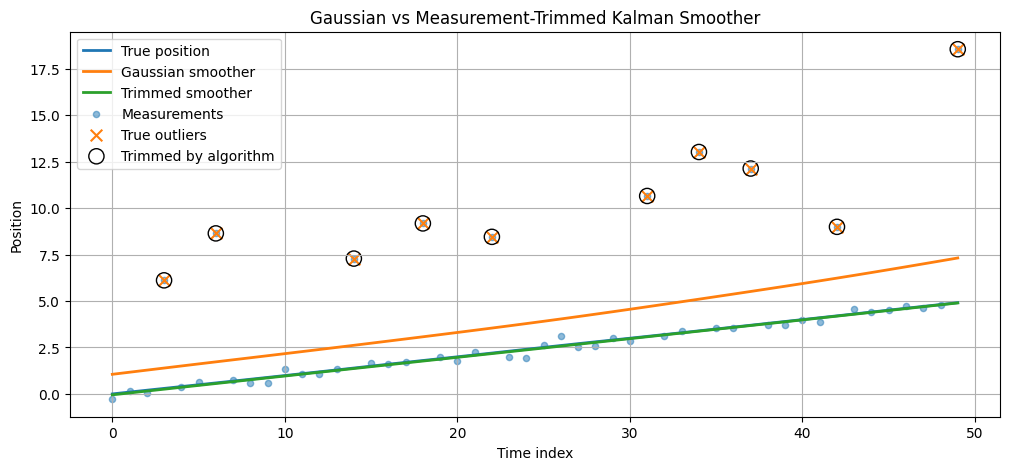

In [5]:
q_trim = N - h
trimmed_idx = np.argsort(omega_trim)[:q_trim]

plt.figure(figsize=(12, 5))
plt.plot(x_true[:, 1], label="True position", linewidth=2)
plt.plot(x_gauss[:, 1], label="Gaussian smoother", linewidth=2)
plt.plot(x_trim[:, 1], label="Trimmed smoother", linewidth=2)
plt.scatter(np.arange(N), z, s=20, alpha=0.5, label="Measurements")
plt.scatter(outlier_idx, z[outlier_idx], s=70, marker="x", label="True outliers")
plt.scatter(trimmed_idx, z[trimmed_idx], s=120,
            facecolors="none", edgecolors="black", label="Trimmed by algorithm")
plt.legend(); plt.title("Gaussian vs Measurement-Trimmed Kalman Smoother")
plt.xlabel("Time index"); plt.ylabel("Position"); plt.grid(True)
plt.show()

In [6]:
# Outlier detection metrics
true_outliers    = set(outlier_idx.tolist())
detected_trimmed = set(trimmed_idx.tolist())
correctly_trimmed = true_outliers & detected_trimmed
false_trimmed     = detected_trimmed - true_outliers

print("True outlier indices:    ", sorted(true_outliers))
print("Algorithm-trimmed indices:", sorted(detected_trimmed))
print("Correctly trimmed:        ", sorted(correctly_trimmed))
print("False trimmed:            ", sorted(false_trimmed))
print("Detection rate:", len(correctly_trimmed) / len(true_outliers))

True outlier indices:     [3, 6, 14, 18, 22, 31, 34, 37, 42, 49]
Algorithm-trimmed indices: [3, 6, 14, 18, 22, 31, 34, 37, 42, 49]
Correctly trimmed:         [3, 6, 14, 18, 22, 31, 34, 37, 42, 49]
False trimmed:             []
Detection rate: 1.0


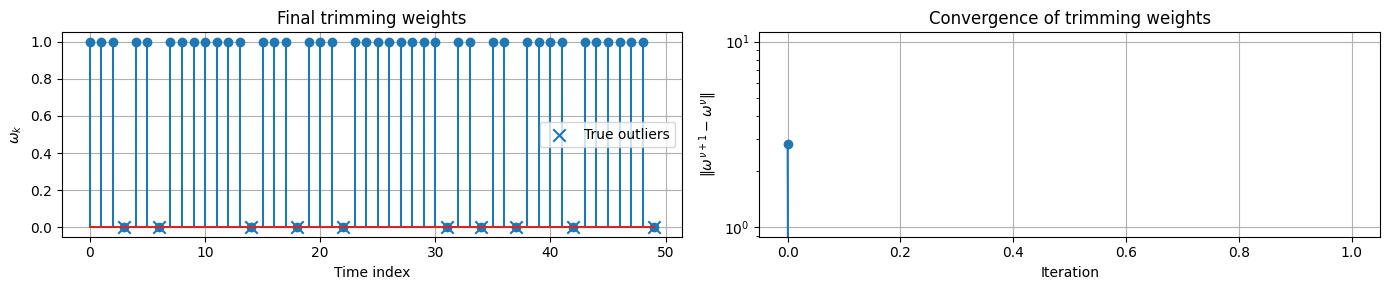

In [7]:
# Weights and convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].stem(np.arange(N), omega_trim)
axes[0].scatter(outlier_idx, omega_trim[outlier_idx], s=80, marker="x", label="True outliers")
axes[0].set_title("Final trimming weights")
axes[0].set_xlabel("Time index"); axes[0].set_ylabel(r"$\omega_k$")
axes[0].set_ylim(-0.05, 1.05); axes[0].grid(True); axes[0].legend()

omega_changes = [item["omega_change"] for item in history]
axes[1].plot(omega_changes, marker="o")
axes[1].set_yscale("log")
axes[1].set_title("Convergence of trimming weights")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel(r"$\|\omega^{\nu+1}-\omega^\nu\|$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 4. Monte Carlo experiment (30 trials)

In [8]:
results = [run_one_trial(seed=s) for s in range(30)]
df = pd.DataFrame(results)
display(df)

cols = ["mse_gaussian", "mse_trimmed", "improvement_factor",
        "detection_rate", "false_trim_rate", "iterations"]
print("\nMeans:")
print(df[cols].mean())
print("\nStd devs:")
print(df[cols].std())

,seed,mse_gaussian,mse_trimmed,improvement_factor,detection_rate,false_trim_rate,iterations
0,0,0.566136,0.002026,279.503581,1.0,0.0,2
1,1,0.641849,0.002658,241.443149,1.0,0.0,2
2,2,0.900068,0.002587,347.946833,1.0,0.0,2
3,3,0.663938,0.002745,241.905489,1.0,0.0,2
4,4,0.877642,0.003822,229.620194,1.0,0.0,2
5,5,0.893267,0.001154,774.377527,1.0,0.0,2
6,6,0.614281,0.001317,466.318893,1.0,0.0,2
7,7,0.496243,0.002073,239.327958,1.0,0.0,2
8,8,0.763973,0.000910,839.104244,1.0,0.0,2
9,9,0.676085,0.000788,857.903227,1.0,0.0,2



Means:
mse_gaussian            0.810771
mse_trimmed             0.001922
improvement_factor    697.066373
detection_rate          1.000000
false_trim_rate         0.000000
iterations              2.000000
dtype: float64

Std devs:
mse_gaussian            0.215421
mse_trimmed             0.001452
improvement_factor    592.069033
detection_rate          0.000000
false_trim_rate         0.000000
iterations              0.000000
dtype: float64


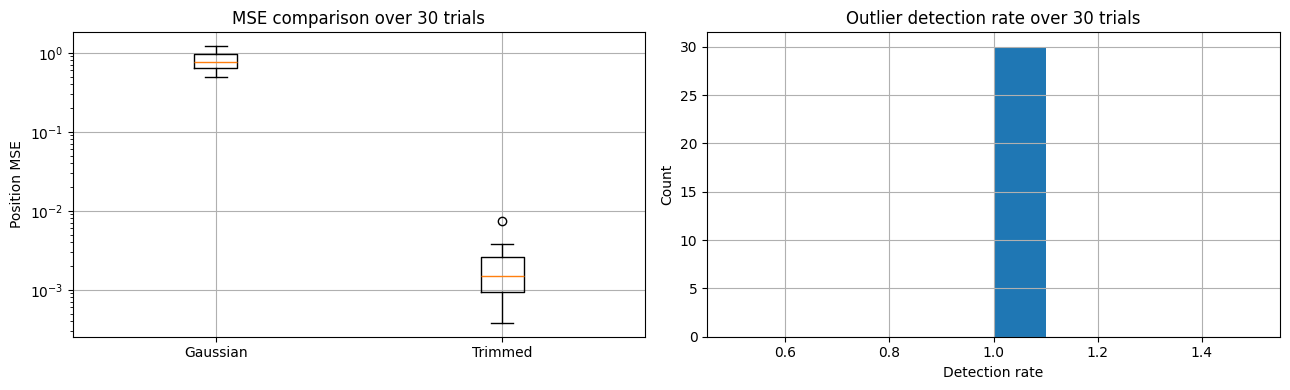

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].boxplot([df["mse_gaussian"], df["mse_trimmed"]],
                tick_labels=["Gaussian", "Trimmed"])
axes[0].set_yscale("log")
axes[0].set_title("MSE comparison over 30 trials")
axes[0].set_ylabel("Position MSE"); axes[0].grid(True)

axes[1].hist(df["detection_rate"], bins=10)
axes[1].set_title("Outlier detection rate over 30 trials")
axes[1].set_xlabel("Detection rate"); axes[1].set_ylabel("Count")
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 5. General smooth damped oscillatory signal — setup

True signal: $s(t) = e^{-\beta t} \sin(\alpha t)$

State: $X_k = [\dot{s}_k,\ s_k]^T$

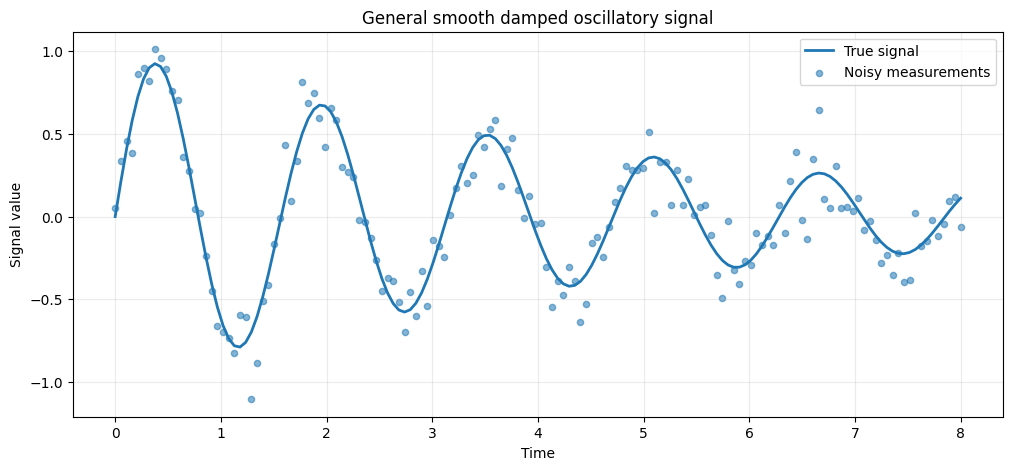

In [10]:
alpha_general = 4.0
beta_general  = 0.2

(
    t_general, x_true_general, z_general,
    G_general, H_general, Q_general, R_general,
) = simulate_general_smooth_signal(
    N=150, t_max=8.0,
    alpha=alpha_general, beta=beta_general,
    process_scale=2.0, meas_std=0.15, seed=1,
)

N_general = len(z_general)
x0_prior_general = np.array([alpha_general, 0.0])

plt.figure(figsize=(12, 5))
plt.plot(t_general, x_true_general[:, 1], linewidth=2, label="True signal")
plt.scatter(t_general, z_general, s=20, alpha=0.55, label="Noisy measurements")
plt.xlabel("Time"); plt.ylabel("Signal value")
plt.title("General smooth damped oscillatory signal")
plt.legend(); plt.grid(alpha=0.25); plt.show()

In [11]:
# Gaussian smoother on clean signal
x_gaussian_general = weighted_batch_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general, z=z_general,
    omega=np.ones(N_general),
    x0_prior=x0_prior_general, P0=np.eye(2),
)

print("Derivative MSE:", np.mean((x_gaussian_general[:, 0] - x_true_general[:, 0])**2))
print("Signal MSE:    ", np.mean((x_gaussian_general[:, 1] - x_true_general[:, 1])**2))

Derivative MSE: 0.05597492009884488
Signal MSE:     0.0017382137283481617


---
## 6. General signal — measurement outlier experiment

In [12]:
z_general_outlier  = z_general.copy()
outlier_idx_general = np.array([18, 42, 67, 91, 116, 138])
outlier_values_general = np.array([2.8, -3.0, 2.5, -2.7, 3.2, -2.9])
z_general_outlier[outlier_idx_general] += outlier_values_general

# Gaussian smoother with outliers
x_gaussian_general_outlier = weighted_batch_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general, z=z_general_outlier,
    omega=np.ones(N_general),
    x0_prior=x0_prior_general, P0=np.eye(2),
)

mse_gaussian_general_outlier_signal = np.mean(
    (x_gaussian_general_outlier[:, 1] - x_true_general[:, 1])**2
)
print("Gaussian signal MSE with outliers:", mse_gaussian_general_outlier_signal)

Gaussian signal MSE with outliers: 0.03946011440324697


In [13]:
# Measurement-trimmed smoother on general signal with outliers
h_general = N_general - len(outlier_idx_general)

(
    x_trimmed_general_outlier,
    omega_trimmed_general_outlier,
    losses_trimmed_general_outlier,
    history_general_outlier,
) = trimmed_kalman_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general,
    z=z_general_outlier,
    h=h_general, gamma=0.5, max_iter=100, tol=1e-8,
    x0_prior=x0_prior_general, P0=np.eye(2),
    verbose=True,
)

num_trimmed_general = N_general - h_general
detected_trimmed_idx_general = np.argsort(omega_trimmed_general_outlier)[:num_trimmed_general]

mse_trimmed_general_outlier_signal = np.mean(
    (x_trimmed_general_outlier[:, 1] - x_true_general[:, 1])**2
)

print("\nTrue outlier indices:   ", np.sort(outlier_idx_general))
print("Detected trimmed indices:", np.sort(detected_trimmed_idx_general))
print("Gaussian signal MSE:    ", mse_gaussian_general_outlier_signal)
print("Trimmed signal MSE:     ", mse_trimmed_general_outlier_signal)
print("Improvement factor:     ",
      mse_gaussian_general_outlier_signal / mse_trimmed_general_outlier_signal)

iter 00 | omega change = 2.400e+00 | min omega = 0.000 | max omega = 1.000
iter 01 | omega change = 0.000e+00 | min omega = 0.000 | max omega = 1.000

True outlier indices:    [ 18  42  67  91 116 138]
Detected trimmed indices: [ 18  42  67  91 116 138]
Gaussian signal MSE:     0.03946011440324697
Trimmed signal MSE:      0.0020128524521314996
Improvement factor:      19.604076971196218


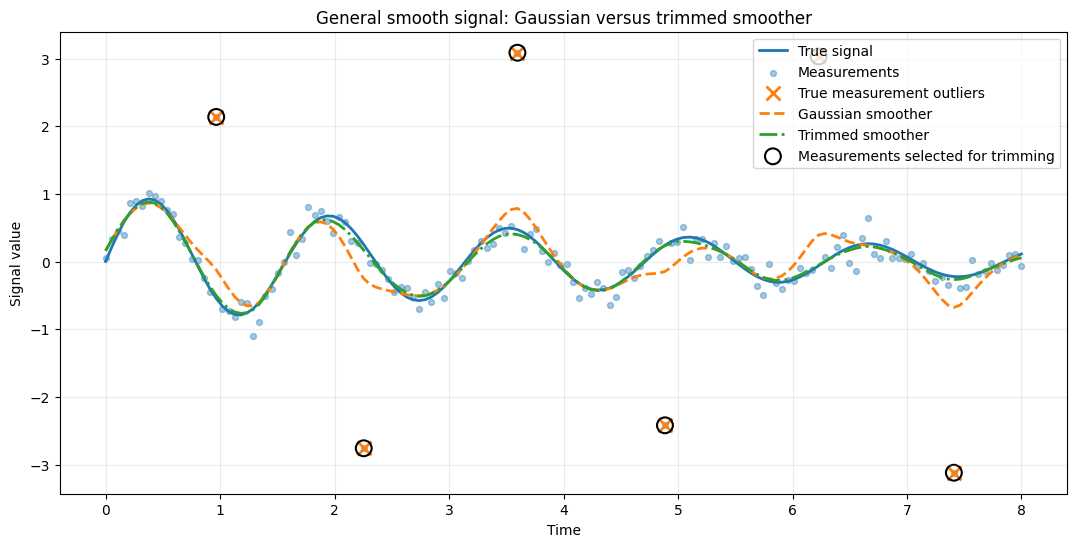

In [14]:
plt.figure(figsize=(13, 6))
plt.plot(t_general, x_true_general[:, 1], linewidth=2, label="True signal")
plt.scatter(t_general, z_general_outlier, s=18, alpha=0.4, label="Measurements")
plt.scatter(t_general[outlier_idx_general], z_general_outlier[outlier_idx_general],
            marker="x", s=100, linewidths=2, label="True measurement outliers")
plt.plot(t_general, x_gaussian_general_outlier[:, 1],
         linestyle="--", linewidth=2, label="Gaussian smoother")
plt.plot(t_general, x_trimmed_general_outlier[:, 1],
         linestyle="-.", linewidth=2, label="Trimmed smoother")
plt.scatter(t_general[detected_trimmed_idx_general],
            z_general_outlier[detected_trimmed_idx_general],
            facecolors="none", edgecolors="black", s=130, linewidths=1.5,
            label="Measurements selected for trimming")
plt.xlabel("Time"); plt.ylabel("Signal value")
plt.title("General smooth signal: Gaussian versus trimmed smoother")
plt.legend(); plt.grid(alpha=0.25); plt.show()

---
## 7. General signal — genuine state-jump experiment

In [15]:
# Inject permanent signal-level jumps into the true state
jump_idx_general    = np.array([30, 80, 125])
jump_values_general = np.array([0.9, -1.2, 0.8])

x_true_general_jump = x_true_general.copy()
for jump_idx, jump_value in zip(jump_idx_general, jump_values_general):
    x_true_general_jump[jump_idx:, 1] += jump_value

# Reuse the same measurement-noise realization
measurement_noise_general = z_general - x_true_general[:, 1]
z_general_jump = x_true_general_jump[:, 1] + measurement_noise_general

print("x_true_general_jump shape:", x_true_general_jump.shape)
print("z_general_jump shape:     ", z_general_jump.shape)
print("Jump indices:", jump_idx_general)
print("Jump values: ", jump_values_general)

x_true_general_jump shape: (150, 2)
z_general_jump shape:      (150,)
Jump indices: [ 30  80 125]
Jump values:  [ 0.9 -1.2  0.8]


In [16]:
# Gaussian smoother on jumped signal
x_gaussian_general_jump = weighted_batch_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general, z=z_general_jump,
    omega=np.ones(N_general),
    x0_prior=x0_prior_general, P0=np.eye(2),
)

mse_gaussian_general_jump_signal = np.mean(
    (x_gaussian_general_jump[:, 1] - x_true_general_jump[:, 1])**2
)
print("Gaussian signal MSE with state jumps:", mse_gaussian_general_jump_signal)

Gaussian signal MSE with state jumps: 0.013360410783328506


In [17]:
# Innovation losses: compare Gaussian vs measurement-trimmed
innovation_residuals_gaussian_jump, innovation_losses_gaussian_jump = \
    compute_innovation_losses(x_gaussian_general_jump, G_general, Q_general)

# Measurement-trimmed on jumped signal (no true measurement outliers)
assumed_num_outliers_general_jump = len(outlier_idx_general)
h_general_jump = N_general - assumed_num_outliers_general_jump

(
    x_trimmed_general_jump,
    omega_trimmed_general_jump,
    losses_trimmed_general_jump,
    history_general_jump,
) = trimmed_kalman_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general,
    z=z_general_jump,
    h=h_general_jump, gamma=0.5, max_iter=100, tol=1e-8,
    x0_prior=x0_prior_general, P0=np.eye(2),
    verbose=True,
)

innovation_residuals_trimmed_jump, innovation_losses_trimmed_jump = \
    compute_innovation_losses(x_trimmed_general_jump, G_general, Q_general)

summary_gaussian = summarize_innovation_loss_near_jumps(
    innovation_losses_gaussian_jump, jump_idx_general, radius=3)
summary_trimmed  = summarize_innovation_loss_near_jumps(
    innovation_losses_trimmed_jump, jump_idx_general, radius=3)

print("Gaussian innovation-loss summary near jumps")
display(summary_gaussian)
print("Trimmed innovation-loss summary near jumps")
display(summary_trimmed)

iter 00 | omega change = 2.167e+00 | min omega = 0.000 | max omega = 1.000
iter 01 | omega change = 5.749e-01 | min omega = 0.000 | max omega = 1.000
iter 02 | omega change = 1.266e-01 | min omega = 0.000 | max omega = 1.000
iter 03 | omega change = 2.119e-01 | min omega = 0.000 | max omega = 1.000
iter 04 | omega change = 3.314e-01 | min omega = 0.000 | max omega = 1.000
iter 05 | omega change = 8.426e-03 | min omega = 0.000 | max omega = 1.000
iter 06 | omega change = 2.069e-02 | min omega = 0.000 | max omega = 1.000
iter 07 | omega change = 5.081e-02 | min omega = 0.000 | max omega = 1.000
iter 08 | omega change = 1.248e-01 | min omega = 0.000 | max omega = 1.000
iter 09 | omega change = 3.069e-01 | min omega = 0.000 | max omega = 1.000
iter 10 | omega change = 7.628e-01 | min omega = 0.000 | max omega = 1.000
iter 11 | omega change = 1.700e-01 | min omega = 0.000 | max omega = 1.000
iter 12 | omega change = 0.000e+00 | min omega = 0.000 | max omega = 1.000
Gaussian innovation-loss 

,jump_idx,transition_idx,local_peak_idx,distance_from_jump_transition,innovation_loss_at_transition,max_innovation_loss_near_jump
0,30,29,32,3,0.168653,2.349297
1,80,79,82,3,0.352593,2.297729
2,125,124,126,2,0.190199,0.654475


Trimmed innovation-loss summary near jumps


,jump_idx,transition_idx,local_peak_idx,distance_from_jump_transition,innovation_loss_at_transition,max_innovation_loss_near_jump
0,30,29,32,3,0.031493,1.523252
1,80,79,82,3,0.014855,1.037543
2,125,124,126,2,0.202280,0.546429


---
## 8. Innovation-trimmed smoother — jump detection

In [18]:
q_innovation              = len(jump_idx_general)
h_innovation_general_jump = (N_general - 1) - q_innovation

(
    x_innovation_trimmed_general_jump,
    nu_innovation_trimmed_general_jump,
    innovation_losses_innovation_trimmed_jump,
    innovation_residuals_innovation_trimmed_jump,
    history_innovation_trimmed_jump,
) = innovation_trimmed_kalman_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general,
    z=z_general_jump,
    h_innovation=h_innovation_general_jump,
    gamma=None, gamma_factor=1.0,
    max_iter=100, tol=1e-8,
    x0_prior=x0_prior_general, P0=np.eye(2),
    verbose=True,
)

Auto scalar-innovation gamma = 0.384253
Max initial scalar-innovation loss = 2.60245
iter 00 | nu change = 9.646e-01 | min nu = 0.555 | max nu = 1.000 | max innovation loss = 2.602e+00
iter 01 | nu change = 8.790e-01 | min nu = 0.010 | max nu = 1.000 | max innovation loss = 5.370e+00
iter 02 | nu change = 7.216e-01 | min nu = 0.000 | max nu = 1.000 | max innovation loss = 1.155e+02
iter 03 | nu change = 0.000e+00 | min nu = 0.000 | max nu = 1.000 | max innovation loss = 5.822e+02


In [19]:
true_jump_transition_idx_general = jump_idx_general - 1

detected_innovation_trimmed_idx = np.argsort(
    nu_innovation_trimmed_general_jump
)[:q_innovation]

print("True jump transition indices:", true_jump_transition_idx_general)
print("Innovation transitions selected for trimming:",
      np.sort(detected_innovation_trimmed_idx))

innovation_detection_rate, innovation_matches = detection_near_jumps(
    detected_innovation_trimmed_idx,
    true_jump_transition_idx_general,
    radius=2,
)
print("\nInnovation-jump detection rate:", innovation_detection_rate)
print("Matched each jump?", innovation_matches)

True jump transition indices: [ 29  79 124]
Innovation transitions selected for trimming: [24 33 82]

Innovation-jump detection rate: 0.0
Matched each jump? [False, False, False]


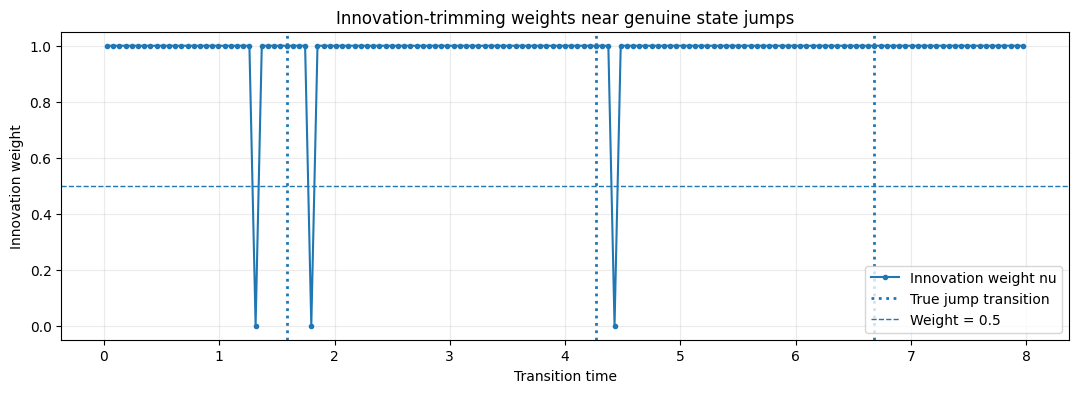

In [20]:
# Plot innovation weights along transition timeline
transition_times_general = 0.5 * (t_general[:-1] + t_general[1:])

plt.figure(figsize=(13, 4))
plt.plot(transition_times_general, nu_innovation_trimmed_general_jump,
         marker="o", markersize=3, linewidth=1.5, label="Innovation weight nu")
for i, transition_idx in enumerate(true_jump_transition_idx_general):
    plt.axvline(transition_times_general[transition_idx], linestyle=":", linewidth=2,
                label="True jump transition" if i == 0 else None)
plt.axhline(0.5, linestyle="--", linewidth=1, label="Weight = 0.5")
plt.xlabel("Transition time"); plt.ylabel("Innovation weight")
plt.title("Innovation-trimming weights near genuine state jumps")
plt.ylim(-0.05, 1.05); plt.legend(); plt.grid(alpha=0.25); plt.show()

---
## 9. Innovation trimming with warm start

In [21]:
L = len(z_general_jump) - 1
h_innovation = L - q_innovation

nu_init, warm_idx, jump_score = warm_start_nu_from_jump_score(
    z_general_jump, h_innovation=h_innovation, small_value=0.1
)

print("Warm-start suspected jump transitions:", warm_idx)
print("True jump transitions:                ", jump_idx_general - 1)

Warm-start suspected jump transitions: [23 29 79]
True jump transitions:                 [ 29  79 124]


In [22]:
(
    x_innov_warm, nu_innov_warm,
    innov_losses_warm, innov_residuals_warm, history_warm,
) = innovation_trimmed_kalman_smoother(
    G=G_general, H=H_general, Q=Q_general, R=R_general,
    z=z_general_jump,
    h_innovation=h_innovation,
    gamma=None, gamma_factor=0.25,
    max_iter=100, tol=1e-8,
    x0_prior=x0_prior_general, P0=np.eye(2),
    nu_init=nu_init, verbose=True,
)

Auto scalar-innovation gamma = 0.00602997
Max initial scalar-innovation loss = 41.4596
iter 00 | nu change = 1.285e-01 | min nu = 0.000 | max nu = 1.000 | max innovation loss = 4.146e+01
iter 01 | nu change = 6.390e-02 | min nu = 0.000 | max nu = 1.000 | max innovation loss = 3.481e+03
iter 02 | nu change = 0.000e+00 | min nu = 0.000 | max nu = 1.000 | max innovation loss = 1.237e+04


In [23]:
q_innovation = L - h_innovation

detected_innov_transitions = np.argsort(nu_innov_warm)[:q_innovation]

print("Detected innovation-trimmed transitions:", detected_innov_transitions)
print("True jump transitions:                 ", jump_idx_general - 1)
print("Final nu at detected transitions:       ", nu_innov_warm[detected_innov_transitions])

Detected innovation-trimmed transitions: [29 23 79]
True jump transitions:                  [ 29  79 124]
Final nu at detected transitions:        [0. 0. 0.]


In [24]:
detection_rate, matched = detection_near_jumps(
    detected_idx=detected_innov_transitions,
    true_transition_idx=jump_idx_general - 1,
    radius=2,
)

print("Detection rate near jumps:", detection_rate)
print("Matched each jump?       ", matched)

Detection rate near jumps: 0.6666666666666666
Matched each jump?        [True, True, False]


In [25]:
x_gauss_general_jump = weighted_batch_smoother(
    G=G_general,
    H=H_general,
    Q=Q_general,
    R=R_general,
    z=z_general_jump,
    omega=np.ones(len(z_general_jump)),
    nu=np.ones(len(z_general_jump) - 1),
    x0_prior=x0_prior_general,
    P0=np.eye(2),
)

In [26]:
mse_gauss_jump = np.mean(
    (x_gauss_general_jump[:, 1] - x_true_general_jump[:, 1]) ** 2
)

mse_innov_jump = np.mean(
    (x_innov_warm[:, 1] - x_true_general_jump[:, 1]) ** 2
)

print("Gaussian signal MSE:           ", mse_gauss_jump)
print("Innovation-trimmed signal MSE: ", mse_innov_jump)
print("Improvement factor:            ", mse_gauss_jump / mse_innov_jump)

Gaussian signal MSE:            0.013360410783328506
Innovation-trimmed signal MSE:  0.007166668952658941
Improvement factor:             1.864242770467526


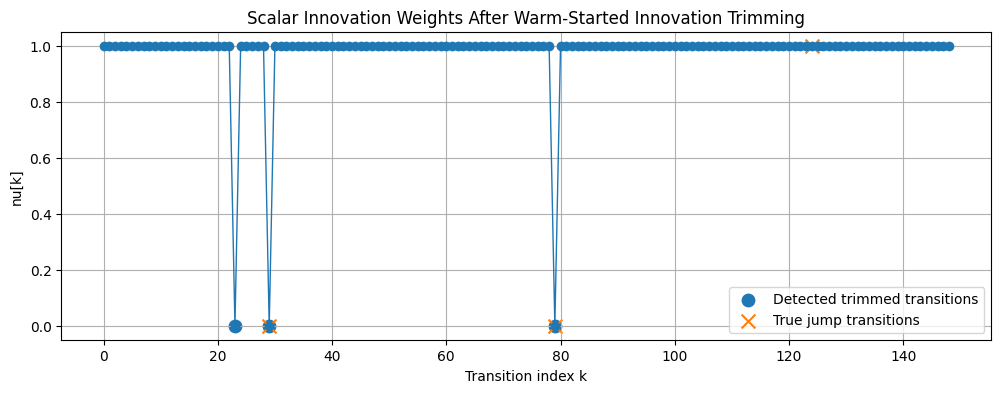

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(nu_innov_warm, marker="o", linewidth=1)
plt.scatter(
    detected_innov_transitions,
    nu_innov_warm[detected_innov_transitions],
    s=80,
    label="Detected trimmed transitions",
)
plt.scatter(
    jump_idx_general - 1,
    nu_innov_warm[jump_idx_general - 1],
    marker="x",
    s=100,
    label="True jump transitions",
)
plt.title("Scalar Innovation Weights After Warm-Started Innovation Trimming")
plt.xlabel("Transition index k")
plt.ylabel("nu[k]")
plt.legend()
plt.grid(True)
plt.show()

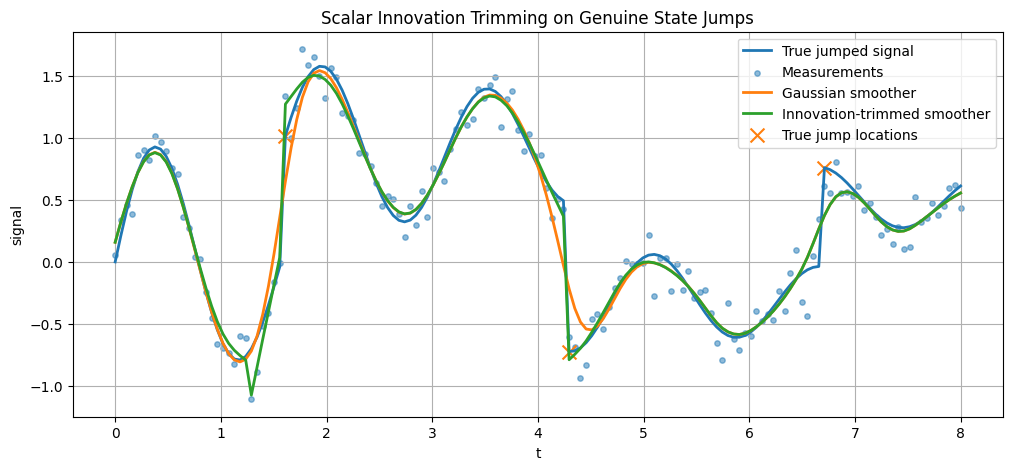

In [28]:
plt.figure(figsize=(12, 5))

plt.plot(t_general, x_true_general_jump[:, 1], label="True jumped signal", linewidth=2)
plt.scatter(t_general, z_general_jump, s=15, alpha=0.5, label="Measurements")
plt.plot(t_general, x_gauss_general_jump[:, 1], label="Gaussian smoother", linewidth=2)
plt.plot(t_general, x_innov_warm[:, 1], label="Innovation-trimmed smoother", linewidth=2)

plt.scatter(
    t_general[jump_idx_general],
    x_true_general_jump[jump_idx_general, 1],
    marker="x",
    s=100,
    label="True jump locations",
)

plt.title("Scalar Innovation Trimming on Genuine State Jumps")
plt.xlabel("t")
plt.ylabel("signal")
plt.legend()
plt.grid(True)
plt.show()